# CONFIGURATION PARAMETERS

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from matplotlib.ticker import MultipleLocator
import re
import os
import numpy as np
from matplotlib.lines import Line2D

# import data
cb_10x = os.path.join("..", "..", "..", "se", "new", "clean-files-ul", "aggr", "agg-cb-10.csv")
cf_10x_aggr = os.path.join("..","..", "..", "se","new","clean-files-ul", "aggr", "agg-cf-10-agg.csv")
cb_5x = os.path.join("..","..", "..", "se","new","clean-files-ul", "aggr", "agg-cb-5.csv")
cf_5x_aggr = os.path.join("..","..", "..", "se","new","clean-files-ul", "aggr", "agg-cf-5-agg.csv")
cb_1x = os.path.join("..","..", "..", "se","new","clean-files-ul", "aggr", "agg-cb-1.csv")
cf_1x_aggr = os.path.join("..","..", "..", "se","new","clean-files-ul", "aggr", "agg-cf-1-agg.csv")

In [ ]:
# Read content of the file
df_cb_1 = pd.read_csv(cb_1x)
df_cf_1_aggr = pd.read_csv(cf_1x_aggr)

def read_data_by_ue(csv_path): 
  df = pd.read_csv(csv_path)

  dfs = {}

  for ue_id, group in df.groupby("UE_ID"):
    df_ue = group.sort_values("Time_ms").reset_index(drop=True)
    df_ue["Rolling Avg (bit/s/Hz)"] = df_ue["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5, min_periods=1).mean()
    dfs[ue_id] = df_ue
  
  return dfs

dfs_cb_5 = read_data_by_ue(cb_5x)
dfs_cf_5_aggr = read_data_by_ue(cf_5x_aggr)

def read_data_by_ue(csv_path): 
  df = pd.read_csv(csv_path)

  dfs = {}

  for ue_id, group in df.groupby("UE_ID"):
    df_ue = group.sort_values("Time_ms").reset_index(drop=True)
    df_ue["Rolling Avg (bit/s/Hz)"] = df_ue["Mean_UL_SE_bit_per_s_Hz"].rolling(window=5, min_periods=1).mean()
    dfs[ue_id] = df_ue
  
  return dfs

dfs_cb_10 = read_data_by_ue(cb_10x)
dfs_cf_10_aggr = read_data_by_ue(cf_10x_aggr)

# DESCRIBE

In [10]:
print(df_cb_1["Mean_UL_SE_bit_per_s_Hz"].describe())
print(df_cf_1_aggr["Mean_UL_SE_bit_per_s_Hz"].describe())

count    899.000000
mean      20.769042
std        0.080757
min       19.917435
25%       20.778000
50%       20.778000
75%       20.778000
max       20.778000
Name: Mean_UL_SE_bit_per_s_Hz, dtype: float64
count    901.000000
mean      28.598404
std        0.064922
min       27.637635
25%       28.565164
50%       28.600233
75%       28.637058
max       28.719826
Name: Mean_UL_SE_bit_per_s_Hz, dtype: float64


In [11]:
df_cb_5 = pd.read_csv(cb_5x)
df_cf_5_aggr = pd.read_csv(cf_5x_aggr)

print(df_cb_5["Mean_UL_SE_bit_per_s_Hz"].describe())
print(df_cf_5_aggr["Mean_UL_SE_bit_per_s_Hz"].describe())

count    4505.000000
mean       19.261556
std         1.648777
min        16.993652
25%        17.288000
50%        20.374821
75%        20.778000
max        20.778000
Name: Mean_UL_SE_bit_per_s_Hz, dtype: float64
count    4505.000000
mean       27.570184
std         0.572349
min        25.638711
25%        26.996334
50%        27.755829
75%        27.933622
max        28.471063
Name: Mean_UL_SE_bit_per_s_Hz, dtype: float64


In [12]:
df_cb_10 = pd.read_csv(cb_10x)
df_cf_10_aggr = pd.read_csv(cf_10x_aggr)

print(df_cb_10["Mean_UL_SE_bit_per_s_Hz"].describe())
print(df_cf_10_aggr["Mean_UL_SE_bit_per_s_Hz"].describe())

count    9010.000000
mean       18.498316
std         3.476139
min         6.108520
25%        18.324000
50%        19.567956
75%        20.778000
max        20.778000
Name: Mean_UL_SE_bit_per_s_Hz, dtype: float64
count    1736.000000
mean       22.206233
std         2.170868
min        13.661690
25%        20.766790
50%        22.553721
75%        23.935566
max        25.476397
Name: Mean_UL_SE_bit_per_s_Hz, dtype: float64


# BARPLOTS

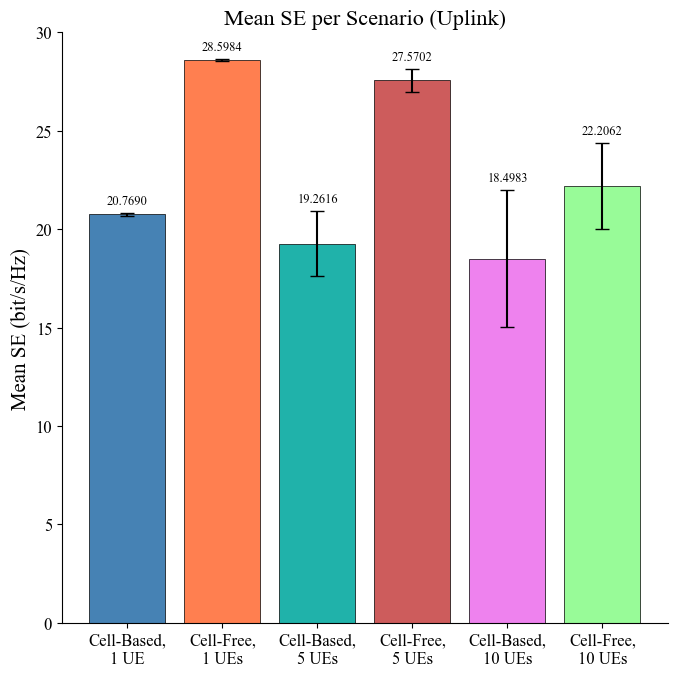

In [ ]:
mean_se_total_1 = df_cb_10['Mean_UL_SE_bit_per_s_Hz'].mean()
mean_se_total_2 = df_cb_5['Mean_UL_SE_bit_per_s_Hz'].mean()
mean_se_total_3 = df_cb_1['Mean_UL_SE_bit_per_s_Hz'].mean()
mean_se_total_41 = df_cf_10_aggr['Mean_UL_SE_bit_per_s_Hz'].mean()
mean_se_total_51 = df_cf_5_aggr['Mean_UL_SE_bit_per_s_Hz'].mean()
mean_se_total_61 = df_cf_1_aggr['Mean_UL_SE_bit_per_s_Hz'].mean()

std_se_total_1 = df_cb_10['Mean_UL_SE_bit_per_s_Hz'].std()
std_se_total_2 = df_cb_5['Mean_UL_SE_bit_per_s_Hz'].std()
std_se_total_3 = df_cb_1['Mean_UL_SE_bit_per_s_Hz'].std()
std_se_total_41 = df_cf_10_aggr['Mean_UL_SE_bit_per_s_Hz'].std()
std_se_total_51 = df_cf_5_aggr['Mean_UL_SE_bit_per_s_Hz'].std()
std_se_total_61 = df_cf_1_aggr['Mean_UL_SE_bit_per_s_Hz'].std()

mean_values = [
    mean_se_total_3,
    mean_se_total_61,
    mean_se_total_2,
    mean_se_total_51,

      mean_se_total_1,
    mean_se_total_41
]

std_values = [
    std_se_total_3,
    std_se_total_61,
    std_se_total_2,
    std_se_total_51,

        std_se_total_1,
    std_se_total_41
]

labels = [
    "Cell-Based,\n1 UE",
    "Cell-Free,\n1 UEs",
    "Cell-Based,\n5 UEs",
    "Cell-Free,\n5 UEs",

        "Cell-Based,\n10 UEs",
    "Cell-Free,\n10 UEs"
]

colors = ["steelblue", 
          "coral", 
          "lightseagreen",
          "indianred",
          "violet", 
          "palegreen",
] 

plt.figure(figsize=(7, 7))
bars = plt.bar(labels, mean_values, color=colors, yerr=std_values, capsize=5,
               edgecolor="black", linewidth=0.5)
plt.title("Mean SE per Scenario (Uplink)")
plt.ylabel("Mean SE (bit/s/Hz)")
plt.ylim(0, 30)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(axis='y')
plt.grid(False)

for i, bar in enumerate(bars):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + std_values[i] + 0.3,
             f"{mean_values[i]:.4f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("figs/mean_se_uplink_cb_cf_aggr.pdf", dpi=300, bbox_inches="tight")
plt.show()

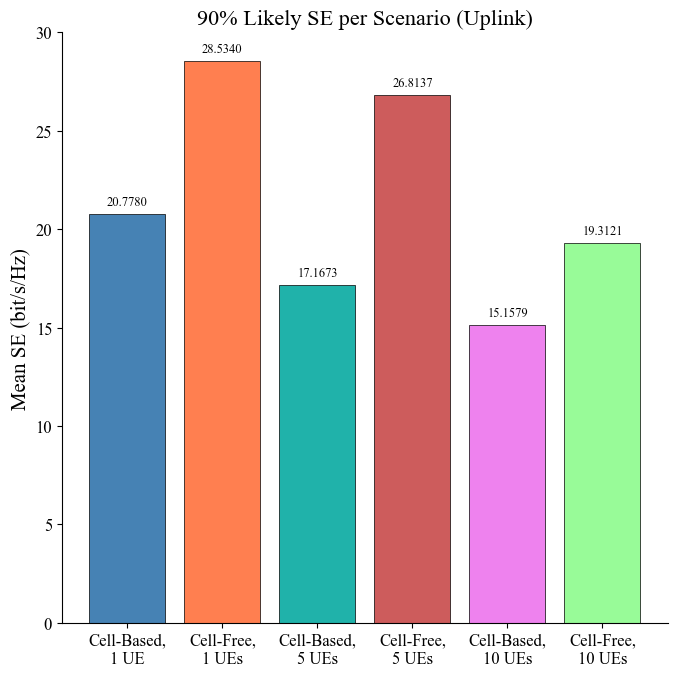

In [ ]:

p10_cf_1_aggr = df_cf_1_aggr['Mean_UL_SE_bit_per_s_Hz'].quantile(0.10)
p10_cf_5_aggr = df_cf_5_aggr['Mean_UL_SE_bit_per_s_Hz'].quantile(0.10)
p10_cf_10_aggr = df_cf_10_aggr['Mean_UL_SE_bit_per_s_Hz'].quantile(0.10)
p10_cb_1 = df_cb_1['Mean_UL_SE_bit_per_s_Hz'].quantile(0.10)
p10_cb_5 = df_cb_5['Mean_UL_SE_bit_per_s_Hz'].quantile(0.10)
p10_cb_10 = df_cb_10['Mean_UL_SE_bit_per_s_Hz'].quantile(0.10)

mean_values = [
    p10_cb_1,
    p10_cf_1_aggr,
    p10_cb_5,
    p10_cf_5_aggr,
    p10_cb_10,
    p10_cf_10_aggr
]

labels = [
    "Cell-Based,\n1 UE",
    "Cell-Free,\n1 UEs",
    "Cell-Based,\n5 UEs",
    "Cell-Free,\n5 UEs",
    "Cell-Based,\n10 UEs",
    "Cell-Free,\n10 UEs"
]

colors = ["steelblue", 
          "coral", 
          "lightseagreen",
          "indianred",
          "violet", 
          "palegreen",
] 

plt.figure(figsize=(7, 7))
bars = plt.bar(labels, mean_values, color=colors, capsize=5,
               edgecolor="black", linewidth=0.5)
plt.title("90% Likely SE per Scenario (Uplink)")
plt.ylabel("Mean SE (bit/s/Hz)")
plt.ylim(0, 30)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(axis='y')
plt.grid(False)

for i, bar in enumerate(bars):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.3,
             f"{mean_values[i]:.4f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("figs/mean_se_90_uplink_cb_cf_aggr.pdf", dpi=300, bbox_inches="tight")
plt.show()

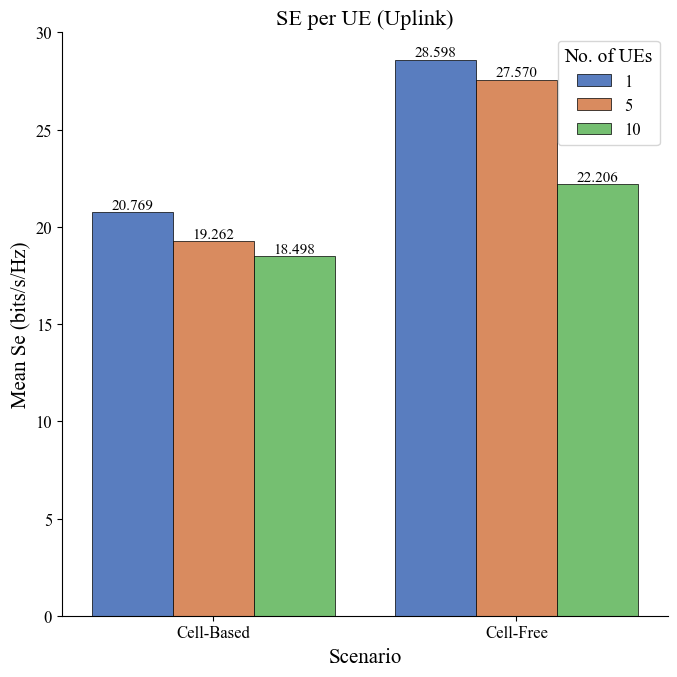

In [ ]:
data = {
    "Nº de UEs": [1, 1, 5, 5, 10, 10],
    "Cenário": ["Cell-Based", "Cell-Free",
                "Cell-Based", "Cell-Free",
                "Cell-Based", "Cell-Free",],
    "SE_total": [
        df_cb_1["Mean_UL_SE_bit_per_s_Hz"].mean(),
        df_cf_1_aggr["Mean_UL_SE_bit_per_s_Hz"].mean(),
        df_cb_5["Mean_UL_SE_bit_per_s_Hz"].mean(),
        df_cf_5_aggr["Mean_UL_SE_bit_per_s_Hz"].mean(),
        df_cb_10["Mean_UL_SE_bit_per_s_Hz"].mean(),
        df_cf_10_aggr["Mean_UL_SE_bit_per_s_Hz"].mean()
    ]
}

df_plot = pd.DataFrame(data)

plt.figure(figsize=(7, 7))
sns.barplot(
    x="Cenário",      
    y="SE_total",
    hue="Nº de UEs",   
    palette="muted",
    edgecolor="black",
    linewidth=0.5,
)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(False)

plt.title("SE per UE (Uplink)")
plt.ylabel("Mean Se (bits/s/Hz)")
plt.xlabel("Scenario")
plt.legend(title="No. of UEs", loc="best")
plt.ylim(0, 30)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2,
            height + 0.01,
            f"{height:.3f}",  
            ha="center", va="bottom",
            fontsize=11, fontfamily="Times New Roman"
        )

plt.tight_layout()
plt.savefig("figs/mean_se_uplink_per_scenario.pdf", dpi=300, bbox_inches="tight")
plt.show()


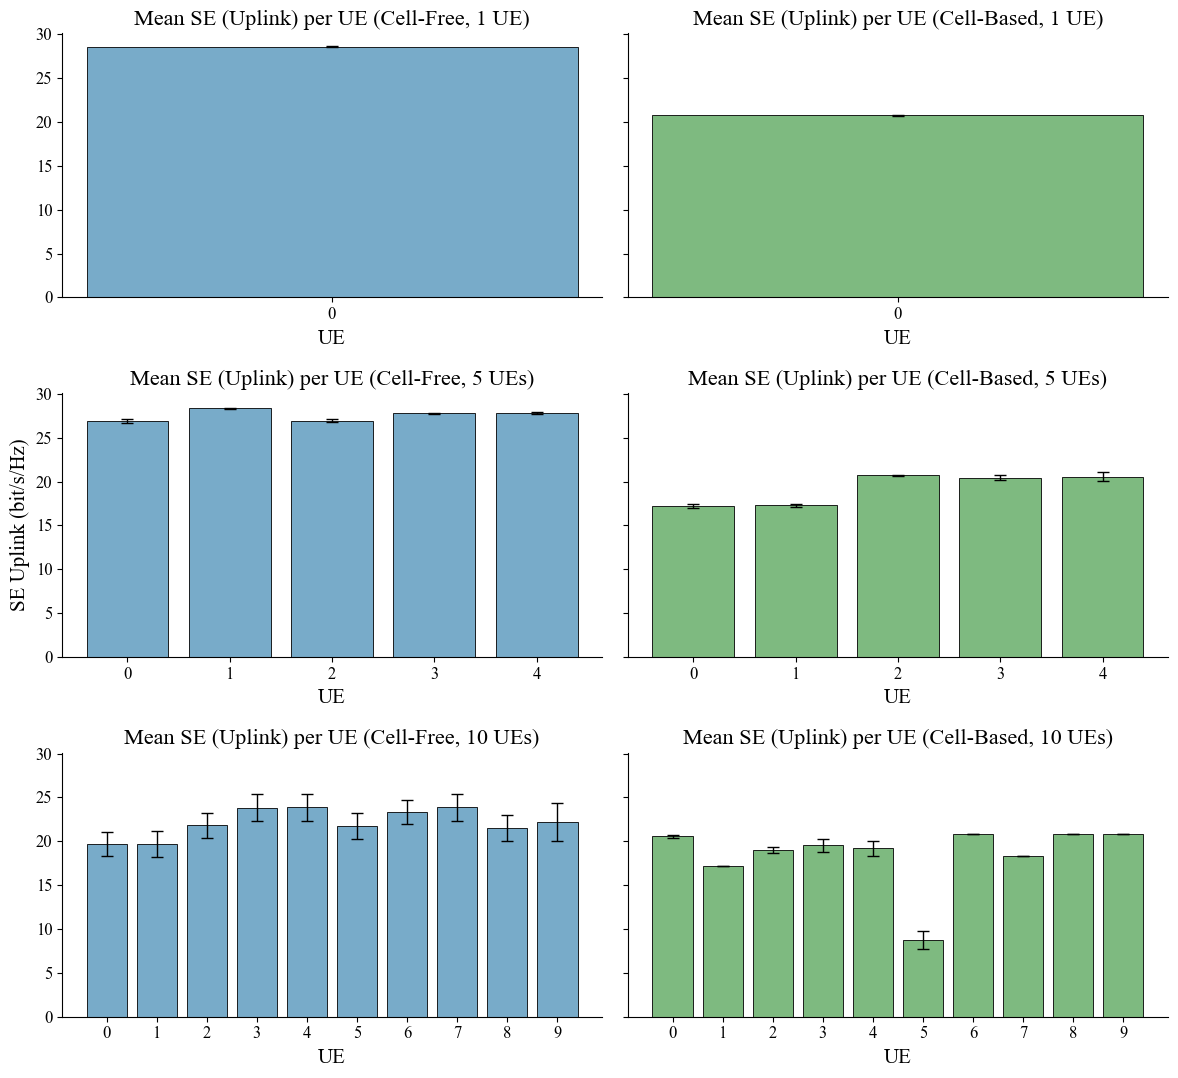

In [ ]:
# CF 10x UEs
df_means_cf_10 = (df_cf_10_aggr
            .groupby("UE_ID")["Mean_UL_SE_bit_per_s_Hz"]
            .agg(mean="mean", std="std")
            .reset_index())

# CB 10x UEs
df_means_cb_10 = (df_cb_10
            .groupby("UE_ID")["Mean_UL_SE_bit_per_s_Hz"]
            .agg(mean="mean", std="std")
            .reset_index())

# CF 5x UEs
df_means_cf_5 = (df_cf_5_aggr
            .groupby("UE_ID")["Mean_UL_SE_bit_per_s_Hz"]
            .agg(mean="mean", std="std")
            .reset_index())

# CB 5x UEs
df_means_cb_5 = (df_cb_5
            .groupby("UE_ID")["Mean_UL_SE_bit_per_s_Hz"]
            .agg(mean="mean", std="std")
            .reset_index())


# CF 1x UEs
df_means_cf_1 = (df_cf_1_aggr
            .groupby("UE_ID")["Mean_UL_SE_bit_per_s_Hz"]
            .agg(mean="mean", std="std")
            .reset_index())

# CB 1x UEs
df_means_cb_1 = (df_cb_1
            .groupby("UE_ID")["Mean_UL_SE_bit_per_s_Hz"]
            .agg(mean="mean", std="std")
            .reset_index())

fig, axes = plt.subplots(3, 2, figsize=(12,11), sharey=True)

configs = [
    (df_means_cf_1, df_means_cb_1, "1 UE"),
    (df_means_cf_5, df_means_cb_5, "5 UEs"),
    (df_means_cf_10, df_means_cb_10, "10 UEs")
]

colors = {"CF": "#6baed6", "CB": "#74c476"}

for row, (df_cf, df_cb, label) in enumerate(configs):
    ax_cf = axes[row, 0]
    sns.barplot(data=df_cf, x="UE_ID", y="mean",
                color=colors["CF"], edgecolor="black", linewidth=0.6,
                errorbar=None, ax=ax_cf)
    ax_cf.errorbar(x=np.arange(len(df_cf)), y=df_cf["mean"], yerr=df_cf["std"],
                   fmt="none", ecolor="black", elinewidth=1, capsize=4)
    ax_cf.set_title(f"Mean SE (Uplink) per UE (Cell-Free, {label})")
    ax_cf.set_xlabel("UE")
    if row == 1: 
        ax_cf.set_ylabel("SE Uplink (bit/s/Hz)")
    else:
        ax_cf.set_ylabel("")
    ax_cf.spines["top"].set_visible(False)
    ax_cf.spines["right"].set_visible(False)
    ax_cf.grid(False)

    ax_cb = axes[row, 1]
    sns.barplot(data=df_cb, x="UE_ID", y="mean",
                color=colors["CB"], edgecolor="black", linewidth=0.6,
                errorbar=None, ax=ax_cb)
    ax_cb.errorbar(x=np.arange(len(df_cb)), y=df_cb["mean"], yerr=df_cb["std"],
                   fmt="none", ecolor="black", elinewidth=1, capsize=4)
    ax_cb.set_title(f"Mean SE (Uplink) per UE (Cell-Based, {label})")
    ax_cb.set_xlabel("UE")
    ax_cb.set_ylabel("")
    ax_cb.spines["top"].set_visible(False)
    ax_cb.spines["right"].set_visible(False)
    ax_cb.grid(False)
    ax_cb.set_xticks(np.arange(len(df_cb)))
    ax_cb.set_xticklabels([str(i) for i in range(len(df_cb))])

plt.tight_layout()
plt.savefig("figs/mean_se_uplink_total_aggr.pdf", dpi=300, bbox_inches="tight")
plt.show()

# BOXPLOTS

#### outliers removal

C:\Users\Ana Gouveia\AppData\Local\Temp\ipykernel_18100\1851873054.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(drop_outliers_iqr, k=1.5))


                   before  after  removed
Scenario                                 
Cell-Based 1 UE       899    899        0
Cell-Based 10 UEs    9010   8109      901
Cell-Based 5 UEs     4505   4505        0
Cell-Free 1 UE        901    899        2
Cell-Free 10 UEs     1736   1730        6
Cell-Free 5 UEs      4505   4505        0


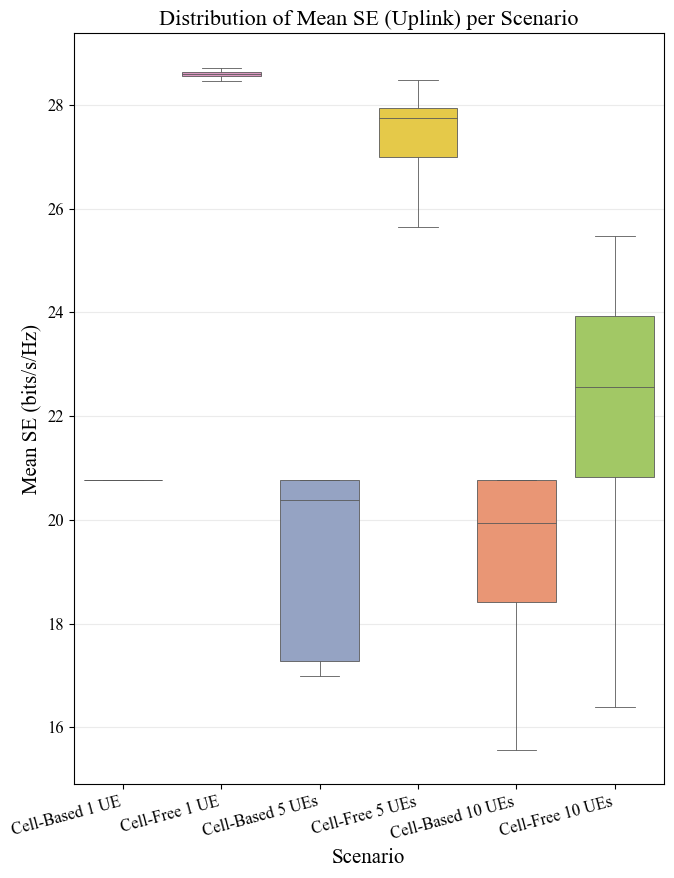

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

order = ['Cell-Based 1 UE','Cell-Free 1 UE',
         'Cell-Based 5 UEs','Cell-Free 5 UEs',
         'Cell-Based 10 UEs','Cell-Free 10 UEs']

df_long = pd.concat([
    df_cb_1.assign(Scenario="Cell-Based 1 UE")[["Scenario", "Mean_UL_SE_bit_per_s_Hz"]],
    df_cf_1_aggr.assign(Scenario="Cell-Free 1 UE")[["Scenario", "Mean_UL_SE_bit_per_s_Hz"]],
    df_cb_5.assign(Scenario="Cell-Based 5 UEs")[["Scenario", "Mean_UL_SE_bit_per_s_Hz"]],
    df_cf_5_aggr.assign(Scenario="Cell-Free 5 UEs")[["Scenario", "Mean_UL_SE_bit_per_s_Hz"]],
    df_cb_10.assign(Scenario="Cell-Based 10 UEs")[["Scenario", "Mean_UL_SE_bit_per_s_Hz"]],
    df_cf_10_aggr.assign(Scenario="Cell-Free 10 UEs")[["Scenario", "Mean_UL_SE_bit_per_s_Hz"]],
], ignore_index=True).rename(columns={"Mean_UL_SE_bit_per_s_Hz": "value"})

def drop_outliers_iqr(g, k=1.5):
    q1 = g["value"].quantile(0.25)
    q3 = g["value"].quantile(0.75)
    iqr = q3 - q1
    if not np.isfinite(iqr) or iqr == 0:
        return g
    lo, hi = q1 - k*iqr, q3 + k*iqr
    return g[(g["value"] >= lo) & (g["value"] <= hi)]

before = df_long.groupby("Scenario")["value"].size()

df_clean = (df_long
            .groupby("Scenario", group_keys=False)
            .apply(drop_outliers_iqr, k=1.5))

after = df_clean.groupby("Scenario")["value"].size()
print(pd.concat([before.rename("before"), after.rename("after"),
                 (before-after).rename("removed")], axis=1))

plt.figure(figsize=(7, 9))
ax = sns.boxplot(data=df_clean, 
                 x="Scenario", 
                 y="value", 
                 hue="Scenario",
                 palette="Set2",
                 linewidth=0.6,
                 order=order, 
                 whis=1.5, 
                 showfliers=False)
ax.set_title("Distribution of Mean SE (Uplink) per Scenario")
ax.set_xlabel("Scenario"); ax.set_ylabel("Mean SE (bits/s/Hz)")
ax.grid(axis='y', alpha=0.25)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig("figs/mean_se_boxplot_no_outliers.pdf", dpi=300, bbox_inches="tight")
plt.show()

# LINE PLOTS

                    before  after  removed
Scenario                                  
Cell-Based 10x UEs    9010   8109      901
Cell-Based 1x UE       899    899        0
Cell-Based 5x UEs     4505   4505        0
Cell-Free 10x UEs     1736   1730        6
Cell-Free 1x UE        901    899        2
Cell-Free 5x UEs      4505   4505        0


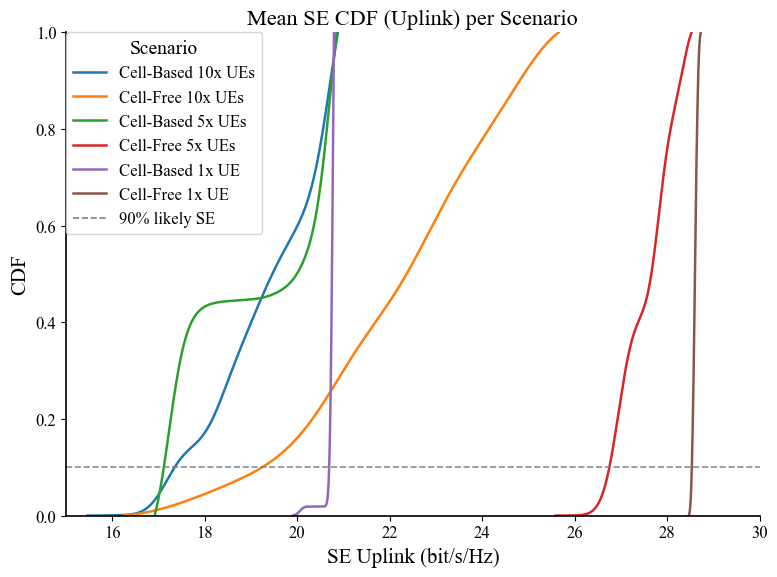

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

df_cb_10["Scenario"] = "Cell-Based 10x UEs"
df_cf_10_aggr["Scenario"] = "Cell-Free 10x UEs"
df_cb_5["Scenario"]  = "Cell-Based 5x UEs"
df_cf_5_aggr["Scenario"]  = "Cell-Free 5x UEs"
df_cb_1["Scenario"]  = "Cell-Based 1x UE"
df_cf_1_aggr["Scenario"]  = "Cell-Free 1x UE"

dfs_to_plot = [
    df_cb_10[["Mean_UL_SE_bit_per_s_Hz","Scenario","UE_ID"]],
    df_cf_10_aggr[["Mean_UL_SE_bit_per_s_Hz","Scenario","UE_ID"]],
    df_cb_5[["Mean_UL_SE_bit_per_s_Hz","Scenario","UE_ID"]],
    df_cf_5_aggr[["Mean_UL_SE_bit_per_s_Hz","Scenario","UE_ID"]],
    df_cb_1[["Mean_UL_SE_bit_per_s_Hz","Scenario","UE_ID"]],
    df_cf_1_aggr[["Mean_UL_SE_bit_per_s_Hz","Scenario","UE_ID"]],
]
df_all = pd.concat(dfs_to_plot, ignore_index=True)
df_all = df_all.dropna(subset=["Mean_UL_SE_bit_per_s_Hz"]).copy()


def smooth_cdf(values, bins=400, sigma_bins=3):
    """ECDF suave via histograma e convolução gaussiana."""
    v = np.asarray(values, float)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return np.array([]), np.array([])
    xmin, xmax = v.min(), v.max()
    pad = 0.02 * (xmax - xmin if xmax > xmin else 1.0)
    edges = np.linspace(xmin - pad, xmax + pad, bins + 1)
    counts, edges = np.histogram(v, bins=edges, density=False)
    khalf = int(4 * sigma_bins)
    kx = np.arange(-khalf, khalf + 1)
    kernel = np.exp(-0.5 * (kx / float(sigma_bins))**2)
    kernel /= kernel.sum()
    smooth_counts = np.convolve(counts, kernel, mode="same")
    cdf = np.cumsum(smooth_counts) / np.sum(smooth_counts)
    x = 0.5 * (edges[:-1] + edges[1:])
    return x, cdf


k = 1.5
g = df_all.groupby("Scenario")["Mean_UL_SE_bit_per_s_Hz"]
q1 = g.transform(lambda s: s.quantile(0.25))
q3 = g.transform(lambda s: s.quantile(0.75))
iqr = q3 - q1
lo, hi = q1 - k*iqr, q3 + k*iqr
mask = ((df_all["Mean_UL_SE_bit_per_s_Hz"] >= lo) &
        (df_all["Mean_UL_SE_bit_per_s_Hz"] <= hi)) | (iqr == 0)
df_no = df_all[mask].copy()

print(
    pd.concat(
        [
            df_all.groupby("Scenario").size().rename("before"),
            df_no.groupby("Scenario").size().rename("after")
        ],
        axis=1
    ).assign(removed=lambda d: d["before"] - d["after"])
)

order = [
    "Cell-Based 10x UEs",
    "Cell-Free 10x UEs",
    "Cell-Based 5x UEs",
    "Cell-Free 5x UEs",
    "Cell-Based 1x UE",
    "Cell-Free 1x UE",
]

pal = plt.get_cmap("tab10").colors
palette_map = {name: pal[i] for i, name in enumerate(order)}

plt.figure(figsize=(8,6))
ax = plt.gca()
for name in order:
    x, y = smooth_cdf(df_no.loc[df_no["Scenario"] == name, "Mean_UL_SE_bit_per_s_Hz"],
                      bins=500, sigma_bins=30)  
    if x.size:
        ax.plot(x, y, lw=1.8, color=palette_map[name], label=name)

y_ref = 0.1
ax.axhline(y=y_ref, ls="--", lw=1.2, color="gray", alpha=0.9)

ax.set_title("Mean SE CDF (Uplink) per Scenario")
ax.set_xlabel("SE Uplink (bit/s/Hz)")
ax.set_ylabel("CDF")
ax.set_xlim(15, 30)
ax.set_ylim(0, 1.0)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(1.2)
ax.spines["left"].set_linewidth(1.2)

handles = [Line2D([0], [0], color=palette_map[name], lw=1.8) for name in order]
labels = order + ["90% likely SE"]
handles.append(Line2D([0], [0], color="gray", lw=1.2, ls="--"))
ax.legend(handles, labels, title="Scenario", loc="upper left", borderaxespad=0.)
plt.tight_layout()
plt.savefig("figs/mean_se_cdf_no_outliers.pdf", dpi=300, bbox_inches="tight")
plt.show()


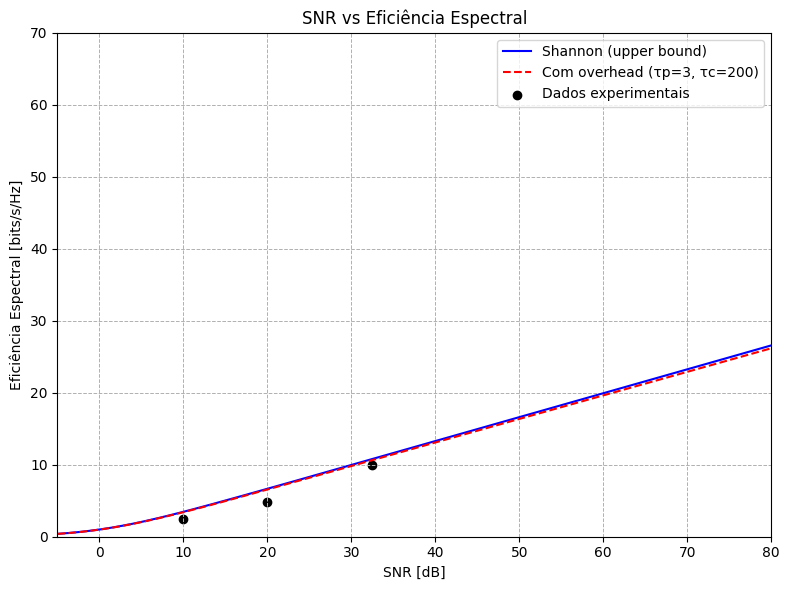

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# SNR in DB
snr_db = np.linspace(-5, 80, 200)
snr_lin = 10**(snr_db/10)           # linear scale

# Shannon (upper bound)
se_shannon = np.log2(1 + snr_lin)

tau_p = 3    
tau_c = 200   
overhead = 1 - (tau_p/tau_c)
se_overhead = overhead * np.log2(1 + snr_lin)

# Plot
plt.figure(figsize=(8,6))
plt.plot(snr_db, se_shannon, label="Shannon (upper bound)", color="blue")
plt.plot(snr_db, se_overhead, label=f"Com overhead (τp={tau_p}, τc={tau_c})", color="red", linestyle="--")

snr_exp_db = [10, 20, 32.47]             # snr values
se_exp = [2.5, 4.8, 9.9]                 # SE values
plt.scatter(snr_exp_db, se_exp, color="black", marker="o", label="Dados experimentais")

plt.xlabel("SNR [dB]")
plt.ylabel("SE [bit/s/Hz]")
plt.ylim(0, 70)
plt.xlim(-5, 80)
plt.title("SNR vs SE")
plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.7)
plt.tight_layout()
plt.show()
